# SOCIAL ANXIETY DATASET — Preprocessing

un this notebook we take the raw file `social_anxiety_dataset.csv` and we make from it a clean and documented dataset.

The work has four stages:

1. we make the profile of every column before any modification, so every decision after that can show the number which justifies it.
2. impossible values, missing values and outliers are handled by the same policy, applied column by column, and we explain each decision in the place where we take it.
3. we cut the continuous columns into labelled groups by using published health guidelines.
4. we build five patterns which are described in the anxiety research, and we check them on our data.

one important point: nothing is changed in a silent way. Every row that we repair keeps a flag about it, and we keep also one untouched copy of the original data, so at the end we can compare the two.

In [59]:
import pandas as pd

from scipy import stats
import matplotlib.pyplot as plt

## 1. LOADING THE DATA

In [60]:
df = pd.read_csv("./social_anxiety_dataset.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2030 entries, 0 to 2029
Data columns (total 22 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                1968 non-null   float64
 1   Gender                             1911 non-null   str    
 2   Occupation                         2030 non-null   str    
 3   Sleep Hours                        1994 non-null   float64
 4   Physical Activity (hrs/week)       2030 non-null   float64
 5   Caffeine Intake (mg/day)           1936 non-null   float64
 6   Alcohol Consumption (drinks/week)  2030 non-null   int64  
 7   Smoking                            1924 non-null   str    
 8   Family History of Anxiety          2030 non-null   str    
 9   Stress Level (1-10)                2030 non-null   int64  
 10  Heart Rate (bpm)                   2030 non-null   int64  
 11  Breathing Rate (breaths/min)       2030 non-null   int64  
 12  Swe

In [61]:
df_raw = df.copy()

In [62]:
n_rows = df.shape[0]
print(f"dataset has {n_rows} data points")

dataset has 2030 data points


In [63]:
n_duplicates = (df.duplicated() == True).sum()
if n_duplicates == 0:
    print("dataset has no duplicate rows")
else:
    print(f"dataset has {n_duplicates} number of duplicate rows")

dataset has no duplicate rows


## 2. WHAT EACH COLUMN MEANS

| column | meaning |
|---|---|
| `Age` | the age of the individual in years |
| `Gender` | gender of the individual |
| `Occupation` | the job of the individual |
| `Sleep Hours` | average hours of sleep per night |
| `Physical Activity (hrs/week)` | total hours of exercise or physical activity per week |
| `Caffeine Intake (mg/day)` | estimated daily consumption of caffeine in milligrams |
| `Alcohol Consumption (drinks/week)` | average alcoholic drinks consumed per week |
| `Smoking` | if the individual smokes or not |
| `Family History of Anxiety` | if blood relatives have a diagnosis of anxiety |
| `Stress Level (1-10)` | self-reported scale of the perceived daily stress |
| `Heart Rate (bpm)` | average measured heart rate in beats per minute |
| `Breathing Rate (breaths/min)` | breathing rate in breaths per minute |
| `Sweating Level (1-5)` | scale of the intensity of sweating, often related to physiological stress |
| `Dizziness` | if the dizziness is present or not |
| `Medication` | if the individual takes a pharmacological treatment |
| `Therapy Sessions (per month)` | counselling or mental health sessions attended each month |
| `Recent Major Life Event` | if a significant stressor happened recently |
| `Diet Quality (1-10)` | self-reported scale of the global quality of the diet |
| `Anxiety Level (1-10)` | self-reported scale of the current severity of anxiety |
| `Target` | if the individual is registered like anxious (`1`) or not (`0`) |
| `is_Anxious` | a second copy of `Target`, identical in every row |
| `Therapy History` | the type of psychological treatment received in the past |

## 3. INSPECTION HELPERS

we have 22 columns and we want to examine all of them in the same way. so instead of writing the same statistics again and again, we write the printing one time, like three functions.

- **`print_general_metrics`** works for any column: the type, how many values it has, how many are missing (in number and in percent), and how many different values exist.
- **`print_numerical_metrics`** works for the measurements. Together with the mean, the standard deviation, the minimum and the maximum, it prints also the **trimmed mean**, the **skewness** (0 means symmetric, a negative value means that the tail is on the left side), the **quartiles**, the number of **1.5x IQR outliers**, and the number of zeros and negatives which can be impossible values.
- **`print_categorical_metrics`** works for the labels: the most frequent value with its percent, and after that the count of every category.

In [64]:
def print_general_metrics(df: pd.DataFrame, col: str):
    target = df[col]

    dtype = target.dtype

    n_rows = target.shape[0]
    n_missing = target.isna().sum()
    n_unique = target.nunique()

    print(f"--- Column `{col}` ---")
    print(f"    {"type":>15}: {dtype}")
    print(f"    {"count":>15}: {n_rows - n_missing}")
    print(f"    {"missing values":>15}: {n_missing} ({n_missing / n_rows * 100:4.2f}%)")
    print(f"    {"unique values":>15}: {n_unique}")
    print()


def print_numerical_metrics(df: pd.DataFrame, col: str):
    target = df[col]

    mean = target.mean()
    std = target.std(ddof=1)

    min_value = target.min()
    max_value = target.max()

    Q1, Q2, Q3 = target.quantile([0.25, 0.5, 0.75])

    lbound = Q1 - (Q3 - Q1) * 1.5
    ubound = Q3 + (Q3 - Q1) * 1.5

    n_outlier = ((target < lbound) | (target > ubound)).sum()
    n_zeros = (target == 0).sum()
    n_negatives = (target < 0).sum()

    print(f"--- Column `{col}` (numerical metrics) ---")
    print(f"    {"mean":>20}: {mean:0.2f}")
    print(f"    {"(trimmed) mean":>20}: {stats.trim_mean(target[~target.isna()], proportiontocut=0.1):0.2f}")
    print(f"    {"standard deviation":>20}: {std:0.2f}")
    print(f"    {"min":>20}: {min_value:0.2f}")
    print(f"    {"max":>20}: {max_value:0.2f}")
    print(f"    {"range":>20}: {max_value - min_value}")
    print(f"    {"mid-range":>20}: {(max_value - min_value) / 2}")
    print(f"    {"skewness":>20}: {target.skew():0.2f}")
    print(f"    {"Q1":>20}: {Q1}")
    print(f"    {"(median) Q2":>20}: {Q2}")
    print(f"    {"Q3":>20}: {Q3}")
    print(f"    {"(1.5x IQR) outliers":>20}: {n_outlier}")
    print(f"    {"anomalies":>20}: zeros: {n_zeros:02d} | negatives: {n_negatives:02d}")
    print()


def print_categorical_metrics(df: pd.DataFrame, col: str):
    target = df[col]

    n_rows = target.shape[0]

    value_counts = target.value_counts()
    mode_value = value_counts.index[0]
    mode_frequency = value_counts.iloc[0]

    print(f"--- Column `{col}` (categorical metrics) ---")
    print(f"    {"mode":>15}: {str(mode_value):s} ({mode_frequency / n_rows * 100:0.2f}%)")
    print()

    print(f"{'Categories:':>15}")
    for value, count in value_counts.items():
        print(f"{value:>15}: {count}")
    print()

## 4. CLEANING POLICY

1. **domain-invalid values** are repaired first. when the true value cannot be recovered — for example a negative number of sleep hours — we treat the entry like a missing value. When the direction of the error is clear, for example a stress score of 15 on a scale which is defined from 1 to 10, we clip the value back on the scale and we flag it.
2. **missing values** are filled after that: the measurement columns with the **mean**, and the label columns with **`Unknown`** when the categories are almost equally spread, or with the **mode** (the most frequent value) when one category is clearly dominant.
3. **outliers** are handled at the end with the 1.5x IQR rule: we record them in a `Outlier Flag` column, and after we cap them on the IQR bounds. We keep the row instead of deleting it, and the flag keeps the information that this value was extreme.

for the choice between `Unknown` and the mode we need a rule, and not a personal decision for every column. we use the **normalized entropy**: the entropy is a standard measure of how much a distribution is spread, and when we divide it by its maximum for this number of categories we obtain a result between `0` and `1`. a perfectly equal split gives `1.00`, and the score goes near `0` when one category becomes dominant.

In [65]:
UNIFORMITY_THRESHOLD = 0.95


def uniformity(series: pd.Series) -> float:
    proportions = series.value_counts(normalize=True)

    if proportions.shape[0] < 2:
        return 0.0

    return stats.entropy(proportions, base=proportions.shape[0])


def handle_outliers(df: pd.DataFrame, column: str):
    Q1, Q3 = df[column].quantile([0.25, 0.75])

    lower_bound = Q1 - (Q3 - Q1) * 1.5
    upper_bound = Q3 + (Q3 - Q1) * 1.5

    outliers = (df[column] < lower_bound) | (df[column] > upper_bound)
    n_outliers = outliers.sum()

    if n_outliers == 0:
        print(f"`{column}`: no (1.5x IQR) outliers")
        return

    df[f"{column} Outlier Flag"] = outliers.astype(int)
    df[column] = df[column].clip(lower=lower_bound, upper=upper_bound)

    print(f"`{column}`: flagged and capped {n_outliers} outliers to [{lower_bound:0.2f}, {upper_bound:0.2f}]")


def fill_numerical(df: pd.DataFrame, column: str):
    n_missing = df[column].isna().sum()
    fill_value = df[column].mean()

    df[column] = df[column].fillna(fill_value)

    print(f"`{column}`: filled {n_missing} missing values with the mean ({fill_value:0.2f})")


def fill_categorical(df: pd.DataFrame, column: str):
    target = df[column]

    n_missing = target.isna().sum()
    score = uniformity(target)

    if score >= UNIFORMITY_THRESHOLD and not pd.api.types.is_numeric_dtype(target):
        fill_value = "Unknown"
    else:
        fill_value = target.mode()[0]

    df[column] = target.fillna(fill_value)

    print(f"`{column}`: uniformity {score:0.3f} | filled {n_missing} missing values with `{fill_value}`")

# 5. SPLITTING THE COLUMNS INTO GROUPS

the policy above treats the measurements and the labels in a different way, so we separate the columns into two lists, and the rest of the notebook works with these lists.

the separation is not only by the data type. `Stress Level (1-10)`, `Sweating Level (1-5)`, `Diet Quality (1-10)` and `Anxiety Level (1-10)` are saved like numbers, but they are self-reported scales with a fixed number of steps and not open measurements, so we put them in the categorical group. for a missing stress score it is better to use a score that a real person gave, and not an average like `6.03` which nobody can answer.

`analyze` only calls the three printing functions together, with switches to skip the parts which are not useful — the numerical metrics of a text column have no meaning, so for these columns we close this part.

In [66]:
numerical_columns = [
    "Age",
    "Sleep Hours",
    "Physical Activity (hrs/week)",
    "Caffeine Intake (mg/day)",
    "Alcohol Consumption (drinks/week)",
    "Heart Rate (bpm)",
    "Breathing Rate (breaths/min)",
    "Therapy Sessions (per month)",
]

categorical_columns = [
    "Gender",
    "Occupation",
    "Smoking",
    "Family History of Anxiety",
    "Stress Level (1-10)",
    "Sweating Level (1-5)",
    "Dizziness",
    "Medication",
    "Recent Major Life Event",
    "Diet Quality (1-10)",
    "Anxiety Level (1-10)",
    "Therapy History",
]

In [67]:
def analyze(df: pd.DataFrame, col: str, general_metrics: bool = True, numerical_metrics: bool = True, categorical_metrics: bool = True):
    if general_metrics:
        print_general_metrics(df, col)

    if numerical_metrics:
        print_numerical_metrics(df, col)

    if categorical_metrics:
        print_categorical_metrics(df, col)

# 6. FIRST LOOK AT EVERY COLUMN

before we change something, we collect the same statistics for all the columns in one time, inside two tables: one for the measurements and one for the labels.

In [68]:
def general_stats(target: pd.Series) -> dict:
    n_rows = target.shape[0]
    n_missing = target.isna().sum()

    return {
        "count": n_rows - n_missing,
        "missing": n_missing,
        "missing_pct": round(n_missing / n_rows * 100, 2),
        "unique": target.nunique(),
    }


def numerical_stats(target: pd.Series) -> dict:
    Q1, Q2, Q3 = target.quantile([0.25, 0.5, 0.75])

    lbound = Q1 - (Q3 - Q1) * 1.5
    ubound = Q3 + (Q3 - Q1) * 1.5

    min_value, max_value = target.min(), target.max()

    return {
        "mean": round(target.mean(), 2),
        "std": round(target.std(ddof=1), 2),
        "min": min_value,
        "max": max_value,
        "range": max_value - min_value,
        "mid_range": (max_value - min_value) / 2,
        "skewness": round(target.skew(), 2),
        "Q1": Q1,
        "median": Q2,
        "Q3": Q3,
        "iqr_outliers": ((target < lbound) | (target > ubound)).sum(),
        "zeros": (target == 0).sum(),
        "negatives": (target < 0).sum(),
    }


def categorical_stats(target: pd.Series) -> dict:
    value_counts = target.value_counts()
    mode_frequency = value_counts.iloc[0]

    return {
        "mode": value_counts.index[0],
        "mode_frequency": mode_frequency,
        "mode_pct": round(mode_frequency / target.shape[0] * 100, 2),
    }


def metrics_frame(df: pd.DataFrame, columns: list[str], metrics) -> pd.DataFrame:
    return pd.DataFrame(
        [
            {"column": column, **general_stats(df[column]), **metrics(df[column])}
            for column in columns
            if column in df.columns
        ]
    ).set_index("column")

In [69]:
metrics_frame(df, numerical_columns, numerical_stats)

,count,missing,missing_pct,unique,mean,std,min,max,range,mid_range,skewness,Q1,median,Q3,iqr_outliers,zeros,negatives
column,,,,,,,,,,,,,,,,,
Age,1968,62,3.05,47,39.92,13.24,18.0,64.0,46.0,23.0,0.11,29.00,40.0,51.0,0,0,0
Sleep Hours,1994,36,1.77,76,6.42,2.16,-10.0,11.0,21.0,10.5,-4.25,5.80,6.7,7.5,52,0,40
Physical Activity (hrs/week),2030,0,0.00,89,2.80,2.23,-10.0,9.2,19.2,9.6,-1.44,1.40,2.8,4.2,33,14,40
Caffeine Intake (mg/day),1936,94,4.63,544,306.28,208.01,0.0,1500.0,1500.0,750.0,2.91,177.75,277.5,391.0,30,2,0
Alcohol Consumption (drinks/week),2030,0,0.00,23,9.49,6.03,-10.0,19.0,29.0,14.5,-0.26,5.00,10.0,15.0,0,95,40
Heart Rate (bpm),2030,0,0.00,61,93.07,23.31,60.0,220.0,160.0,80.0,2.20,76.00,93.0,107.0,30,0,0
Breathing Rate (breaths/min),2030,0,0.00,18,20.96,5.18,12.0,29.0,17.0,8.5,-0.13,17.00,21.0,26.0,0,0,0
Therapy Sessions (per month),2030,0,0.00,11,2.36,2.15,0.0,10.0,10.0,5.0,1.05,1.00,2.0,3.0,119,417,0


In [70]:
metrics_frame(df, categorical_columns, categorical_stats)

,count,missing,missing_pct,unique,mode,mode_frequency,mode_pct
column,,,,,,,
Gender,1911,119,5.86,3,Female,657,32.36
Occupation,2030,0,0.00,13,Student,182,8.97
Smoking,1924,106,5.22,2,Yes,1020,50.25
Family History of Anxiety,2030,0,0.00,2,Yes,1058,52.12
Stress Level (1-10),2030,0,0.00,11,10,264,13.00
Sweating Level (1-5),2030,0,0.00,5,4,436,21.48
Dizziness,2030,0,0.00,2,Yes,1049,51.67
Medication,1921,109,5.37,2,Yes,964,47.49
Recent Major Life Event,2030,0,0.00,2,Yes,1040,51.23


## NORMALITY OF THE DISTRIBUTION

In [71]:
normality_records = []

for column in numerical_columns:
    target = df[column].dropna()

    shapiro_stat, shapiro_p = stats.shapiro(target)
    dagostino_stat, dagostino_p = stats.normaltest(target)

    normality_records.append({
        "column": column,
        "skewness": round(target.skew(), 2),
        "kurtosis": round(target.kurt(), 2),
        "statistic": round(shapiro_stat, 4),
        "p-value": shapiro_p,
        "normal (α=0.05)": int(shapiro_p > 0.05),
    })

normality_df = pd.DataFrame(normality_records).set_index("column")
normality_df

,skewness,kurtosis,statistic,p-value,normal (α=0.05)
column,,,,,
Age,0.11,-1.14,0.9576,1.651636e-23,0
Sleep Hours,-4.25,26.50,0.6494,2.371106e-53,0
Physical Activity (hrs/week),-1.44,7.75,0.8933,2.322604e-35,0
Caffeine Intake (mg/day),2.91,14.39,0.7670,4.069686e-46,0
Alcohol Consumption (drinks/week),-0.26,-0.56,0.9634,2.861331e-22,0
Heart Rate (bpm),2.20,10.64,0.8126,1.508059e-43,0
Breathing Rate (breaths/min),-0.13,-1.18,0.9471,2.074310e-26,0
Therapy Sessions (per month),1.05,0.67,0.8845,1.821924e-36,0


# 7. CLEANING EACH COLUMN

Now every column has its own section, and every section follows the same three steps:

1. **`analyze`** prints the statistics of the column.
2. **a written note** reads these numbers and decides what this column needs, and why.
3. **one cell applies the decision**, with the helper functions of the cleaning policy.

## `Age`

In [72]:
column = "Age"

analyze(df, column, categorical_metrics=False)

--- Column `Age` ---
               type: float64
              count: 1968
     missing values: 62 (3.05%)
      unique values: 47

--- Column `Age` (numerical metrics) ---
                    mean: 39.92
          (trimmed) mean: 39.71
      standard deviation: 13.24
                     min: 18.00
                     max: 64.00
                   range: 46.0
               mid-range: 23.0
                skewness: 0.11
                      Q1: 29.0
             (median) Q2: 40.0
                      Q3: 51.0
     (1.5x IQR) outliers: 0
               anomalies: zeros: 00 | negatives: 00



The `Age` column has valid values between 18 and 64. There is no zero, no negative and no IQR outlier, so here we don't cap and we don't flag anything. For the 62 missing values (3.05%) we use the mean of the column.

In [73]:
fill_numerical(df, "Age")
handle_outliers(df, "Age")

`Age`: filled 62 missing values with the mean (39.92)
`Age`: no (1.5x IQR) outliers


## `Gender`

In [74]:
column = "Gender"

analyze(df, column, numerical_metrics=False)

--- Column `Gender` ---
               type: str
              count: 1911
     missing values: 119 (5.86%)
      unique values: 3

--- Column `Gender` (categorical metrics) ---
               mode: Female (32.36%)

    Categories:
         Female: 657
          Other: 627
           Male: 627



The `Gender` column has three categories which are well balanced, and `Female` is the mode with only 32.36%. No category is dominant enough to impute from it. Its evenness score is at the maximum of the scale, so for the 5.86% of missing answers we create a new category `Unknown`, which marks clearly a non-answer instead of pushing it inside an existing group.

In [75]:
fill_categorical(df, "Gender")

`Gender`: uniformity 1.000 | filled 119 missing values with `Unknown`


## `Occupation`

In [76]:
column = "Occupation"

analyze(df, column, numerical_metrics=False)

--- Column `Occupation` ---
               type: str
              count: 2030
     missing values: 0 (0.00%)
      unique values: 13

--- Column `Occupation` (categorical metrics) ---
               mode: Student (8.97%)

    Categories:
        Student: 182
         Artist: 172
         Lawyer: 167
       Musician: 163
          Nurse: 162
         Doctor: 161
      Scientist: 155
        Teacher: 151
          Other: 149
        Athlete: 147
           Chef: 146
       Engineer: 141
     Freelancer: 134



The `Occupation` column has no missing value and 13 categories distributed in a quite equal way, and `Student` is the mode with only 8.97%. So this column needs no repair.

## `Sleep Hours`

In [77]:
column = "Sleep Hours"

analyze(df, column, categorical_metrics=False)

--- Column `Sleep Hours` ---
               type: float64
              count: 1994
     missing values: 36 (1.77%)
      unique values: 76

--- Column `Sleep Hours` (numerical metrics) ---
                    mean: 6.42
          (trimmed) mean: 6.66
      standard deviation: 2.16
                     min: -10.00
                     max: 11.00
                   range: 21.0
               mid-range: 10.5
                skewness: -4.25
                      Q1: 5.8
             (median) Q2: 6.7
                      Q3: 7.5
     (1.5x IQR) outliers: 52
               anomalies: zeros: 00 | negatives: 40



the `Sleep Hours` column has 40 negative entries. a negative night of sleep has no value that we can recover, so we don't cap these rows but we make them missing. like this we remove also the group of `-10` which pushes the skew until `-4.25`.

after that all the missing values — the 36 original ones plus the 40 negatives that we just removed — are filled with the mean, and the 1.5x IQR outliers of this filled column are flagged in `Sleep Hours Outlier Flag` and capped on its bounds.

In [78]:
df.loc[df["Sleep Hours"] < 0, "Sleep Hours"] = float("nan")

fill_numerical(df, "Sleep Hours")
handle_outliers(df, "Sleep Hours")

`Sleep Hours`: filled 76 missing values with the mean (6.67)
`Sleep Hours`: flagged and capped 29 outliers to [3.75, 9.75]


## `Physical Activity (hrs/week)`

In [79]:
column = "Physical Activity (hrs/week)"

analyze(df, column, categorical_metrics=False)

--- Column `Physical Activity (hrs/week)` ---
               type: float64
              count: 2030
     missing values: 0 (0.00%)
      unique values: 89

--- Column `Physical Activity (hrs/week)` (numerical metrics) ---
                    mean: 2.80
          (trimmed) mean: 2.83
      standard deviation: 2.23
                     min: -10.00
                     max: 9.20
                   range: 19.2
               mid-range: 9.6
                skewness: -1.44
                      Q1: 1.4
             (median) Q2: 2.8
                      Q3: 4.2
     (1.5x IQR) outliers: 33
               anomalies: zeros: 14 | negatives: 40



The `Physical Activity (hrs/week)` column has no missing value, but 40 rows (1.97%) have a negative number of hours. We make these rows missing, we fill the holes with the mean, and after that the 1.5x IQR outliers are flagged and capped.

In [80]:
df.loc[df["Physical Activity (hrs/week)"] < 0, "Physical Activity (hrs/week)"] = float("nan")

fill_numerical(df, "Physical Activity (hrs/week)")
handle_outliers(df, "Physical Activity (hrs/week)")

`Physical Activity (hrs/week)`: filled 40 missing values with the mean (2.98)
`Physical Activity (hrs/week)`: flagged and capped 10 outliers to [-2.30, 8.10]


## `Caffeine Intake (mg/day)`

In [81]:
column = "Caffeine Intake (mg/day)"

analyze(df, column, categorical_metrics=False)

--- Column `Caffeine Intake (mg/day)` ---
               type: float64
              count: 1936
     missing values: 94 (4.63%)
      unique values: 544

--- Column `Caffeine Intake (mg/day)` (numerical metrics) ---
                    mean: 306.28
          (trimmed) mean: 285.84
      standard deviation: 208.01
                     min: 0.00
                     max: 1500.00
                   range: 1500.0
               mid-range: 750.0
                skewness: 2.91
                      Q1: 177.75
             (median) Q2: 277.5
                      Q3: 391.0
     (1.5x IQR) outliers: 30
               anomalies: zeros: 02 | negatives: 00



The `Caffeine Intake (mg/day)` column goes from 0 to 1500mg, with a strong right skew and 30 IQR outliers in the high part, and these outliers push the mean much higher than the median.

This is the column where the order of our policy costs the most: we fill the 4.63% of missing values before we cap the tail, so the filled value is near 306mg and not near the 294mg that we obtain from a capped distribution. The capping after that brings the tail inside and leaves nothing outside of the IQR bounds, and `Caffeine Intake (mg/day) Outlier Flag` keeps the concerned rows identifiable.

In [82]:
fill_numerical(df, "Caffeine Intake (mg/day)")
handle_outliers(df, "Caffeine Intake (mg/day)")

`Caffeine Intake (mg/day)`: filled 94 missing values with the mean (306.28)
`Caffeine Intake (mg/day)`: flagged and capped 30 outliers to [-118.50, 685.50]


## `Alcohol Consumption (drinks/week)`

In [83]:
column = "Alcohol Consumption (drinks/week)"

analyze(df, column, categorical_metrics=False)

--- Column `Alcohol Consumption (drinks/week)` ---
               type: int64
              count: 2030
     missing values: 0 (0.00%)
      unique values: 23

--- Column `Alcohol Consumption (drinks/week)` (numerical metrics) ---
                    mean: 9.49
          (trimmed) mean: 9.64
      standard deviation: 6.03
                     min: -10.00
                     max: 19.00
                   range: 29
               mid-range: 14.5
                skewness: -0.26
                      Q1: 5.0
             (median) Q2: 10.0
                      Q3: 15.0
     (1.5x IQR) outliers: 0
               anomalies: zeros: 95 | negatives: 40



The `Alcohol Consumption (drinks/week)` column has no missing value, but 40 rows have a negative number of drinks.

Here the IQR rule alone cannot find them: with `Q1` at 5 and `Q3` at 15 the lower bound falls exactly on `-10`, and this is exactly the position of the invalid entries. So we make them missing in an explicit way, and after we fill them with the mean.

In [84]:
df.loc[df["Alcohol Consumption (drinks/week)"] < 0, "Alcohol Consumption (drinks/week)"] = float("nan")

fill_numerical(df, "Alcohol Consumption (drinks/week)")
handle_outliers(df, "Alcohol Consumption (drinks/week)")

`Alcohol Consumption (drinks/week)`: filled 40 missing values with the mean (9.79)
`Alcohol Consumption (drinks/week)`: no (1.5x IQR) outliers


## `Smoking`

In [85]:
column = "Smoking"

analyze(df, column, numerical_metrics=False)

--- Column `Smoking` ---
               type: str
              count: 1924
     missing values: 106 (5.22%)
      unique values: 2

--- Column `Smoking` (categorical metrics) ---
               mode: Yes (50.25%)

    Categories:
            Yes: 1020
             No: 904



The `Smoking` column is a split of almost 53/47, so its evenness score passes our threshold, and the 5.22% of missing answers become `Unknown`. Like this they are not pushed on `Yes` only because of a difference of three points.

In [86]:
fill_categorical(df, "Smoking")

`Smoking`: uniformity 0.997 | filled 106 missing values with `Unknown`


## `Family History of Anxiety`

In [87]:
column = "Family History of Anxiety"

analyze(df, column, numerical_metrics=False)

--- Column `Family History of Anxiety` ---
               type: str
              count: 2030
     missing values: 0 (0.00%)
      unique values: 2

--- Column `Family History of Anxiety` (categorical metrics) ---
               mode: Yes (52.12%)

    Categories:
            Yes: 1058
             No: 972



The `Family History of Anxiety` column has no missing value and the split is almost equal, so it needs no repair.

## `Stress Level (1-10)`

In [88]:
column = "Stress Level (1-10)"

analyze(df, column)

--- Column `Stress Level (1-10)` ---
               type: int64
              count: 2030
     missing values: 0 (0.00%)
      unique values: 11

--- Column `Stress Level (1-10)` (numerical metrics) ---
                    mean: 6.03
          (trimmed) mean: 6.06
      standard deviation: 3.14
                     min: 1.00
                     max: 15.00
                   range: 14
               mid-range: 7.0
                skewness: 0.08
                      Q1: 3.0
             (median) Q2: 6.0
                      Q3: 9.0
     (1.5x IQR) outliers: 0
               anomalies: zeros: 00 | negatives: 00

--- Column `Stress Level (1-10)` (categorical metrics) ---
               mode: 10 (13.00%)

    Categories:
             10: 264
              9: 249
              8: 245
              1: 185
              6: 181
              3: 180
              7: 177
              2: 177
              5: 175
              4: 167
             15: 30



The `Stress Level (1-10)` column has no missing value, and the distribution is symmetric and well spread between 1 and 10. But 30 rows (1.48%) have the value 15, which stays outside of the scale 1-10 that the column declares. We don't delete these rows: we flag them in a new column `High Stress Flag` and we clip the value to 10. Like this we keep the information of a very high stress, which is probably real, instead of losing it.

In [89]:
df["High Stress Flag"] = 0
df.loc[df["Stress Level (1-10)"] > 10, "High Stress Flag"] = 1
df["Stress Level (1-10)"] = df["Stress Level (1-10)"].clip(upper=10)

## `Heart Rate (bpm)`

In [90]:
column = "Heart Rate (bpm)"

analyze(df, column, categorical_metrics=False)

--- Column `Heart Rate (bpm)` ---
               type: int64
              count: 2030
     missing values: 0 (0.00%)
      unique values: 61

--- Column `Heart Rate (bpm)` (numerical metrics) ---
                    mean: 93.07
          (trimmed) mean: 91.92
      standard deviation: 23.31
                     min: 60.00
                     max: 220.00
                   range: 160
               mid-range: 80.0
                skewness: 2.20
                      Q1: 76.0
             (median) Q2: 93.0
                      Q3: 107.0
     (1.5x IQR) outliers: 30
               anomalies: zeros: 00 | negatives: 00



The `Heart Rate (bpm)` column has no missing value. It has a right skew and 30 IQR outliers which arrive until 220 bpm — this is physiologically very extreme, but it stays possible for a person during an acute anxiety or panic episode. So we don't delete these rows: we flag them in `Heart Rate (bpm) Outlier Flag` and we cap them on the IQR bounds. Like this the rows stay inside the dataset but their influence becomes limited.

In [91]:
handle_outliers(df, "Heart Rate (bpm)")

`Heart Rate (bpm)`: flagged and capped 30 outliers to [29.50, 153.50]


## `Breathing Rate (breaths/min)`

In [92]:
column = "Breathing Rate (breaths/min)"

analyze(df, column, categorical_metrics=False)

--- Column `Breathing Rate (breaths/min)` ---
               type: int64
              count: 2030
     missing values: 0 (0.00%)
      unique values: 18

--- Column `Breathing Rate (breaths/min)` (numerical metrics) ---
                    mean: 20.96
          (trimmed) mean: 21.05
      standard deviation: 5.18
                     min: 12.00
                     max: 29.00
                   range: 17
               mid-range: 8.5
                skewness: -0.13
                      Q1: 17.0
             (median) Q2: 21.0
                      Q3: 26.0
     (1.5x IQR) outliers: 0
               anomalies: zeros: 00 | negatives: 00



The `Breathing Rate (breaths/min)` column has no missing value, a distribution which is quite symmetric, and no IQR outlier. So it passes through the pipeline without modification and it receives no flag column.

In [93]:
handle_outliers(df, "Breathing Rate (breaths/min)")

`Breathing Rate (breaths/min)`: no (1.5x IQR) outliers


## `Sweating Level (1-5)`

In [94]:
column = "Sweating Level (1-5)"

analyze(df, column)

--- Column `Sweating Level (1-5)` ---
               type: int64
              count: 2030
     missing values: 0 (0.00%)
      unique values: 5

--- Column `Sweating Level (1-5)` (numerical metrics) ---
                    mean: 3.10
          (trimmed) mean: 3.12
      standard deviation: 1.39
                     min: 1.00
                     max: 5.00
                   range: 4
               mid-range: 2.0
                skewness: -0.10
                      Q1: 2.0
             (median) Q2: 3.0
                      Q3: 4.0
     (1.5x IQR) outliers: 0
               anomalies: zeros: 00 | negatives: 00

--- Column `Sweating Level (1-5)` (categorical metrics) ---
               mode: 4 (21.48%)

    Categories:
              4: 436
              3: 434
              5: 426
              2: 374
              1: 360



The `Sweating Level (1-5)` column has no missing value and the distribution is almost symmetric (skew = -0.10). The list of categories confirms that all the values stay inside the declared scale 1-5, and `4` is a light mode with 21.48%. This column needs no repair.

## `Dizziness`

In [95]:
column = "Dizziness"

analyze(df, column, numerical_metrics=False)

--- Column `Dizziness` ---
               type: str
              count: 2030
     missing values: 0 (0.00%)
      unique values: 2

--- Column `Dizziness` (categorical metrics) ---
               mode: Yes (51.67%)

    Categories:
            Yes: 1049
             No: 981



The `Dizziness` column has no missing value and an almost equal split, so we don't touch it.

## `Medication`

In [96]:
column = "Medication"

analyze(df, column, numerical_metrics=False)

--- Column `Medication` ---
               type: str
              count: 1921
     missing values: 109 (5.37%)
      unique values: 2

--- Column `Medication` (categorical metrics) ---
               mode: Yes (47.49%)

    Categories:
            Yes: 964
             No: 957



The `Medication` column has a split which is almost perfectly equal — 964 against 957 — and this makes it the most uniform binary column of the dataset. With the mode we push 109 rows on one class only because of a difference of seven rows, and this is arbitrary. So the missing answers are filled with `Unknown`.

In [97]:
fill_categorical(df, "Medication")

`Medication`: uniformity 1.000 | filled 109 missing values with `Unknown`


## `Therapy Sessions (per month)`

In [98]:
column = "Therapy Sessions (per month)"

analyze(df, column, categorical_metrics=False)

--- Column `Therapy Sessions (per month)` ---
               type: int64
              count: 2030
     missing values: 0 (0.00%)
      unique values: 11

--- Column `Therapy Sessions (per month)` (numerical metrics) ---
                    mean: 2.36
          (trimmed) mean: 2.07
      standard deviation: 2.15
                     min: 0.00
                     max: 10.00
                   range: 10
               mid-range: 5.0
                skewness: 1.05
                      Q1: 1.0
             (median) Q2: 2.0
                      Q3: 3.0
     (1.5x IQR) outliers: 119
               anomalies: zeros: 417 | negatives: 00



The `Therapy Sessions (per month)` column has no missing value. It has a right skew, 417 zeros which are legitimate, and 119 IQR outliers in the high part, and these high values stay possible for people inside an intensive treatment. So we don't delete these rows: we flag them in `Therapy Sessions (per month) Outlier Flag` and we cap them on the IQR bounds, so the rows stay but their influence becomes limited.

In [99]:
handle_outliers(df, "Therapy Sessions (per month)")

`Therapy Sessions (per month)`: flagged and capped 119 outliers to [-2.00, 6.00]


## `Recent Major Life Event`

In [100]:
column = "Recent Major Life Event"

analyze(df, column, numerical_metrics=False)

--- Column `Recent Major Life Event` ---
               type: str
              count: 2030
     missing values: 0 (0.00%)
      unique values: 2

--- Column `Recent Major Life Event` (categorical metrics) ---
               mode: Yes (51.23%)

    Categories:
            Yes: 1040
             No: 990



The `Recent Major Life Event` column has no missing value and an almost equal split (1040 `Yes` against 990 `No`), so it needs no repair. We use it again later, like one half of the indicator `Inherited Risk Triggered`.

## `Diet Quality (1-10)`

In [101]:
column = "Diet Quality (1-10)"

analyze(df, column)

--- Column `Diet Quality (1-10)` ---
               type: float64
              count: 1952
     missing values: 78 (3.84%)
      unique values: 10

--- Column `Diet Quality (1-10)` (numerical metrics) ---
                    mean: 5.23
          (trimmed) mean: 5.18
      standard deviation: 2.88
                     min: 1.00
                     max: 10.00
                   range: 9.0
               mid-range: 4.5
                skewness: 0.12
                      Q1: 3.0
             (median) Q2: 5.0
                      Q3: 8.0
     (1.5x IQR) outliers: 0
               anomalies: zeros: 00 | negatives: 00

--- Column `Diet Quality (1-10)` (categorical metrics) ---
               mode: 3.0 (11.03%)

    Categories:
            3.0: 224
            2.0: 223
            1.0: 221
            4.0: 210
            6.0: 190
            8.0: 185
            7.0: 179
            9.0: 175
           10.0: 173
            5.0: 172



The `Diet Quality (1-10)` column is an ordinal scale which is well spread, it has no IQR outlier, and the list of categories confirms that all the values stay inside the declared range 1-10.

In [102]:
fill_categorical(df, "Diet Quality (1-10)")

`Diet Quality (1-10)`: uniformity 0.998 | filled 78 missing values with `3.0`


## `Anxiety Level (1-10)`

In [103]:
column = "Anxiety Level (1-10)"

analyze(df, column)

--- Column `Anxiety Level (1-10)` ---
               type: float64
              count: 2030
     missing values: 0 (0.00%)
      unique values: 10

--- Column `Anxiety Level (1-10)` (numerical metrics) ---
                    mean: 3.92
          (trimmed) mean: 3.68
      standard deviation: 2.14
                     min: 1.00
                     max: 10.00
                   range: 9.0
               mid-range: 4.5
                skewness: 1.00
                      Q1: 2.0
             (median) Q2: 4.0
                      Q3: 5.0
     (1.5x IQR) outliers: 60
               anomalies: zeros: 00 | negatives: 00

--- Column `Anxiety Level (1-10)` (categorical metrics) ---
               mode: 3.0 (21.18%)

    Categories:
            3.0: 430
            4.0: 424
            2.0: 329
            5.0: 303
            1.0: 206
            6.0: 128
            8.0: 68
           10.0: 60
            9.0: 56
            7.0: 26



The `Anxiety Level (1-10)` column has no missing value, and the list of categories confirms that all the values stay inside the declared scale 1-10. So it needs no repair.

## `Target`

In [104]:
column = "Target"

analyze(df, column, numerical_metrics=False)

--- Column `Target` ---
               type: int64
              count: 2030
     missing values: 0 (0.00%)
      unique values: 2

--- Column `Target` (categorical metrics) ---
               mode: 0 (89.66%)

    Categories:
              0: 1820
              1: 210



The `Target` column has no missing value and contains a simple result `0` / `1`, with 210 anxious persons from 2030.

## `is_Anxious`

In [105]:
column = "is_Anxious"

analyze(df, column, numerical_metrics=False)

--- Column `is_Anxious` ---
               type: int64
              count: 2030
     missing values: 0 (0.00%)
      unique values: 2

--- Column `is_Anxious` (categorical metrics) ---
               mode: 0 (89.66%)

    Categories:
              0: 1820
              1: 210



The `is_Anxious` column has no missing value and it is identical to `Target` in all the 2030 rows. 

In [106]:
df = df.drop(columns=["is_Anxious"])

## `Therapy History`

In [107]:
column = "Therapy History"

analyze(df, column, numerical_metrics=False)

--- Column `Therapy History` ---
               type: str
              count: 203
     missing values: 1827 (90.00%)
      unique values: 4

--- Column `Therapy History` (categorical metrics) ---
               mode: No previous history (2.96%)

    Categories:
No previous history: 60
  Group Therapy: 54
Cognitive Behavioral Therapy (CBT): 45
Psychodynamic Therapy: 44



the `Therapy History` column is missing for 90.00% of the records, and this makes the *type* of therapy unusable — 203 observations divided on four modalities cannot support an analysis.

before any recoding, one contradiction must be repaired. `Therapy History` and `Therapy Sessions (per month)` describe the same treatment, and 45 persons declare zero session but they carry anyway a history value. the two answers cannot be true together, and between them the session count is the one which is complete on all the 2030 rows, so it wins: for these 45 rows we clear the history value. after this repair the column keeps 158 observed histories and its missing part becomes 92.22%.

our first idea was to drop the column completely, but like this we lose the only information which stays reliable: if a record exists or not, and if its absence can be explained because the person doesn't follow a therapy. So instead of deleting, we recode the column into three states.

| value | rule | rows |
|---|---|---|
| `Available` | a history is recorded and the person attends a therapy | 158 |
| `Nothing` | no session attended, so there was nothing to record | 417 |
| `Unavailable` | no history recorded but the person attends a therapy, so the record is really missing | 1455 |

the limit of this recoding must be said clearly. after the repair the record is missing for 90.2% of the people who follow a therapy, and for the people who follow none it is missing everywhere because we cleared it ourselves. so the *pattern* of the missing values says finally nothing, and the separation `Nothing` / `Unavailable` repeats now exactly the question "is `Therapy Sessions (per month)` equal to zero". from the three states, `Available` is the only one which brings an information that the rest of the dataset doesn't have already.

In [108]:
raw_history = df_raw["Therapy History"]
no_sessions = df["Therapy Sessions (per month)"] == 0

contradicted = no_sessions & raw_history.notna()
df["Therapy History"] = raw_history.mask(contradicted)
print(f"cleared {contradicted.sum()} histories contradicted by zero sessions")

has_history = df["Therapy History"].notna()

df["Therapy History"] = "Unavailable"
df.loc[no_sessions, "Therapy History"] = "Nothing"
df.loc[has_history, "Therapy History"] = "Available"

print(df["Therapy History"].value_counts().to_string())

cleared 45 histories contradicted by zero sessions
Therapy History
Unavailable    1455
Nothing         417
Available       158


# 8. CHECKING THE CLEANED DATASET

all the columns are repaired now, so this cell verifies the three things that our policy promises.

**all the 2030 rows are still here.** we never delete a row. in a first version of this notebook we dropped the rows with missing values, and this costs 246 persons — 12% of the dataset — only because of some incomplete columns. When we fill instead of dropping, we keep also all the other answers of these persons.

In [109]:
print(f"rows retained: {df.shape[0]} of {df_raw.shape[0]}")
print(f"remaining missing values: {df.isna().sum().sum()}")
print(f"flag columns: {[c for c in df.columns if c.endswith('Flag')]}")

df.info()

rows retained: 2030 of 2030
remaining missing values: 0
flag columns: ['Sleep Hours Outlier Flag', 'Physical Activity (hrs/week) Outlier Flag', 'Caffeine Intake (mg/day) Outlier Flag', 'High Stress Flag', 'Heart Rate (bpm) Outlier Flag', 'Therapy Sessions (per month) Outlier Flag']
<class 'pandas.DataFrame'>
RangeIndex: 2030 entries, 0 to 2029
Data columns (total 27 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Age                                        2030 non-null   float64
 1   Gender                                     2030 non-null   str    
 2   Occupation                                 2030 non-null   str    
 3   Sleep Hours                                2030 non-null   float64
 4   Physical Activity (hrs/week)               2030 non-null   float64
 5   Caffeine Intake (mg/day)                   2030 non-null   float64
 6   Alcohol Consumption (drinks/week)       

## 9. BEFORE VS AFTER CLEANING

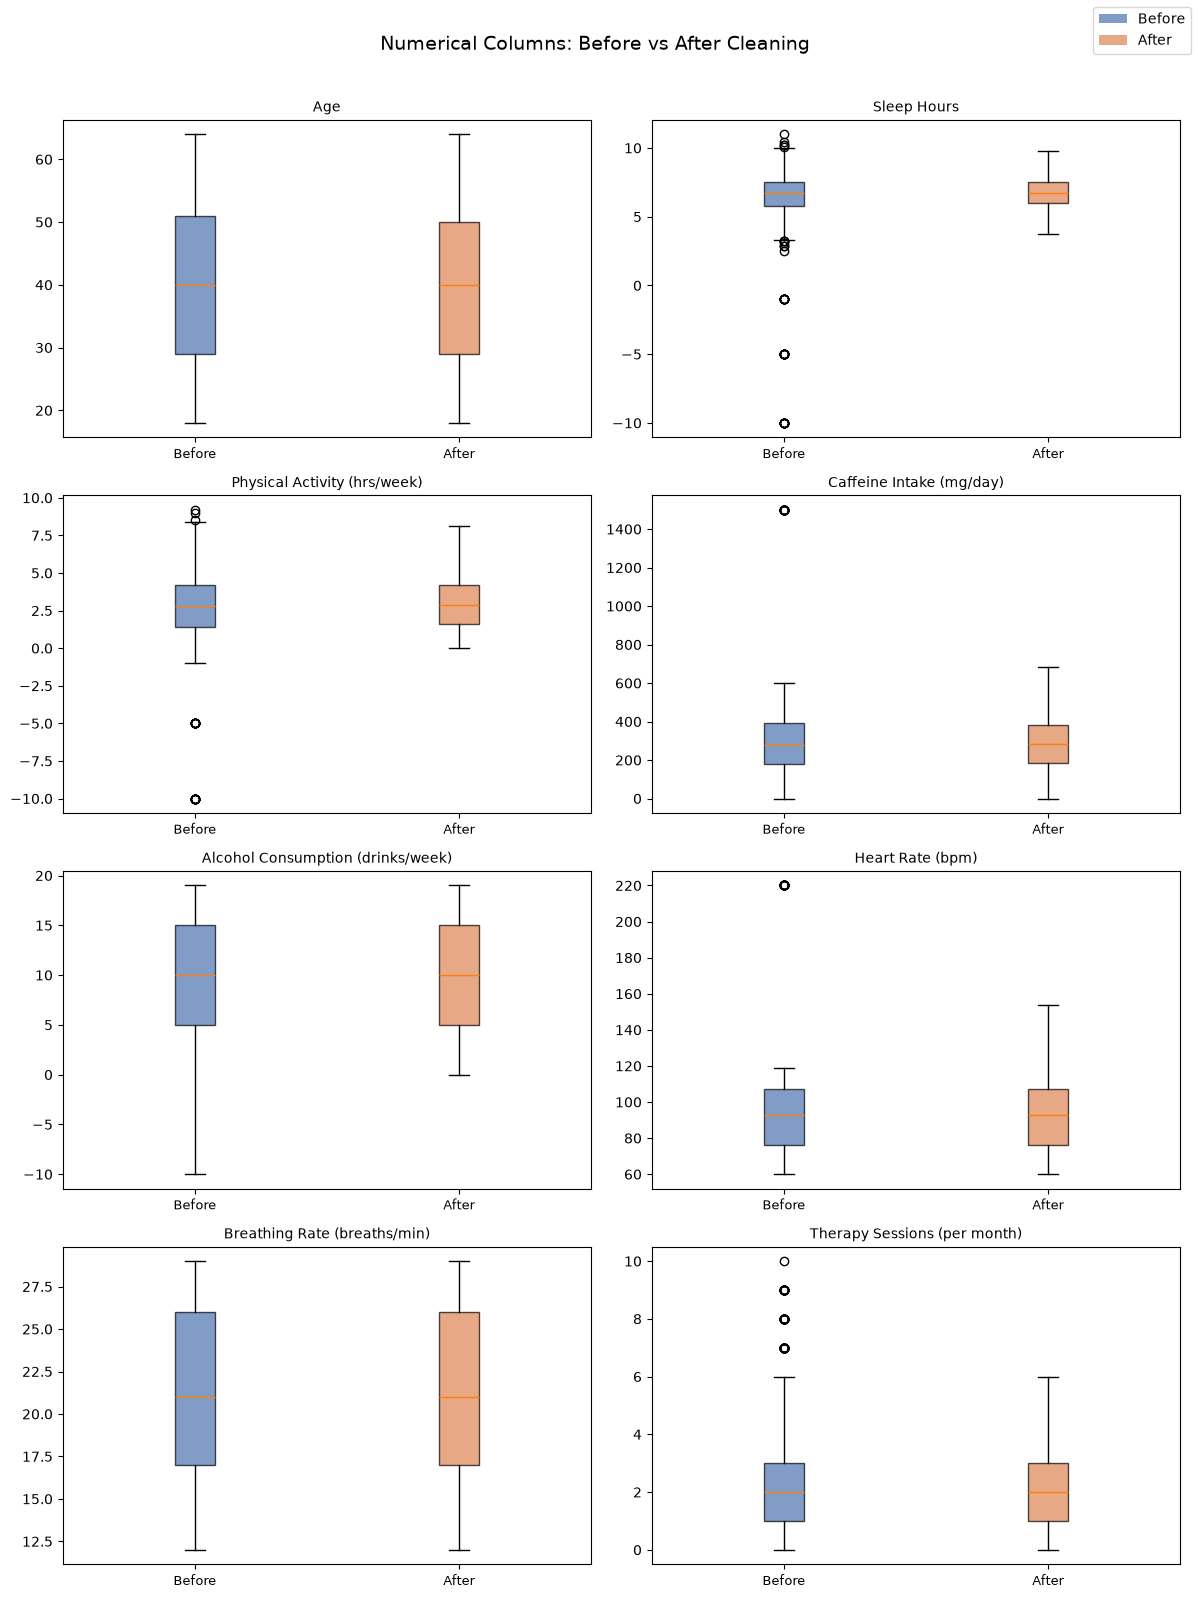

In [110]:
from matplotlib.patches import Patch

before_color = "#4C72B0"
after_color = "#DD8452"

fig, axes = plt.subplots(4, 2, figsize=(12, 16))
axes = axes.flatten()

for ax, column in zip(axes, numerical_columns):
    before = df_raw[column].dropna()
    after = df[column].dropna()

    bp = ax.boxplot([before, after], tick_labels=["Before", "After"], patch_artist=True)
    for patch, color in zip(bp["boxes"], [before_color, after_color]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    ax.set_title(column, fontsize=10)
    ax.tick_params(axis="x", labelsize=9)

legend_elements = [
    Patch(facecolor=before_color, alpha=0.7, label="Before"),
    Patch(facecolor=after_color, alpha=0.7, label="After"),
]
fig.legend(handles=legend_elements, loc="upper right")
fig.suptitle("Numerical Columns: Before vs After Cleaning", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

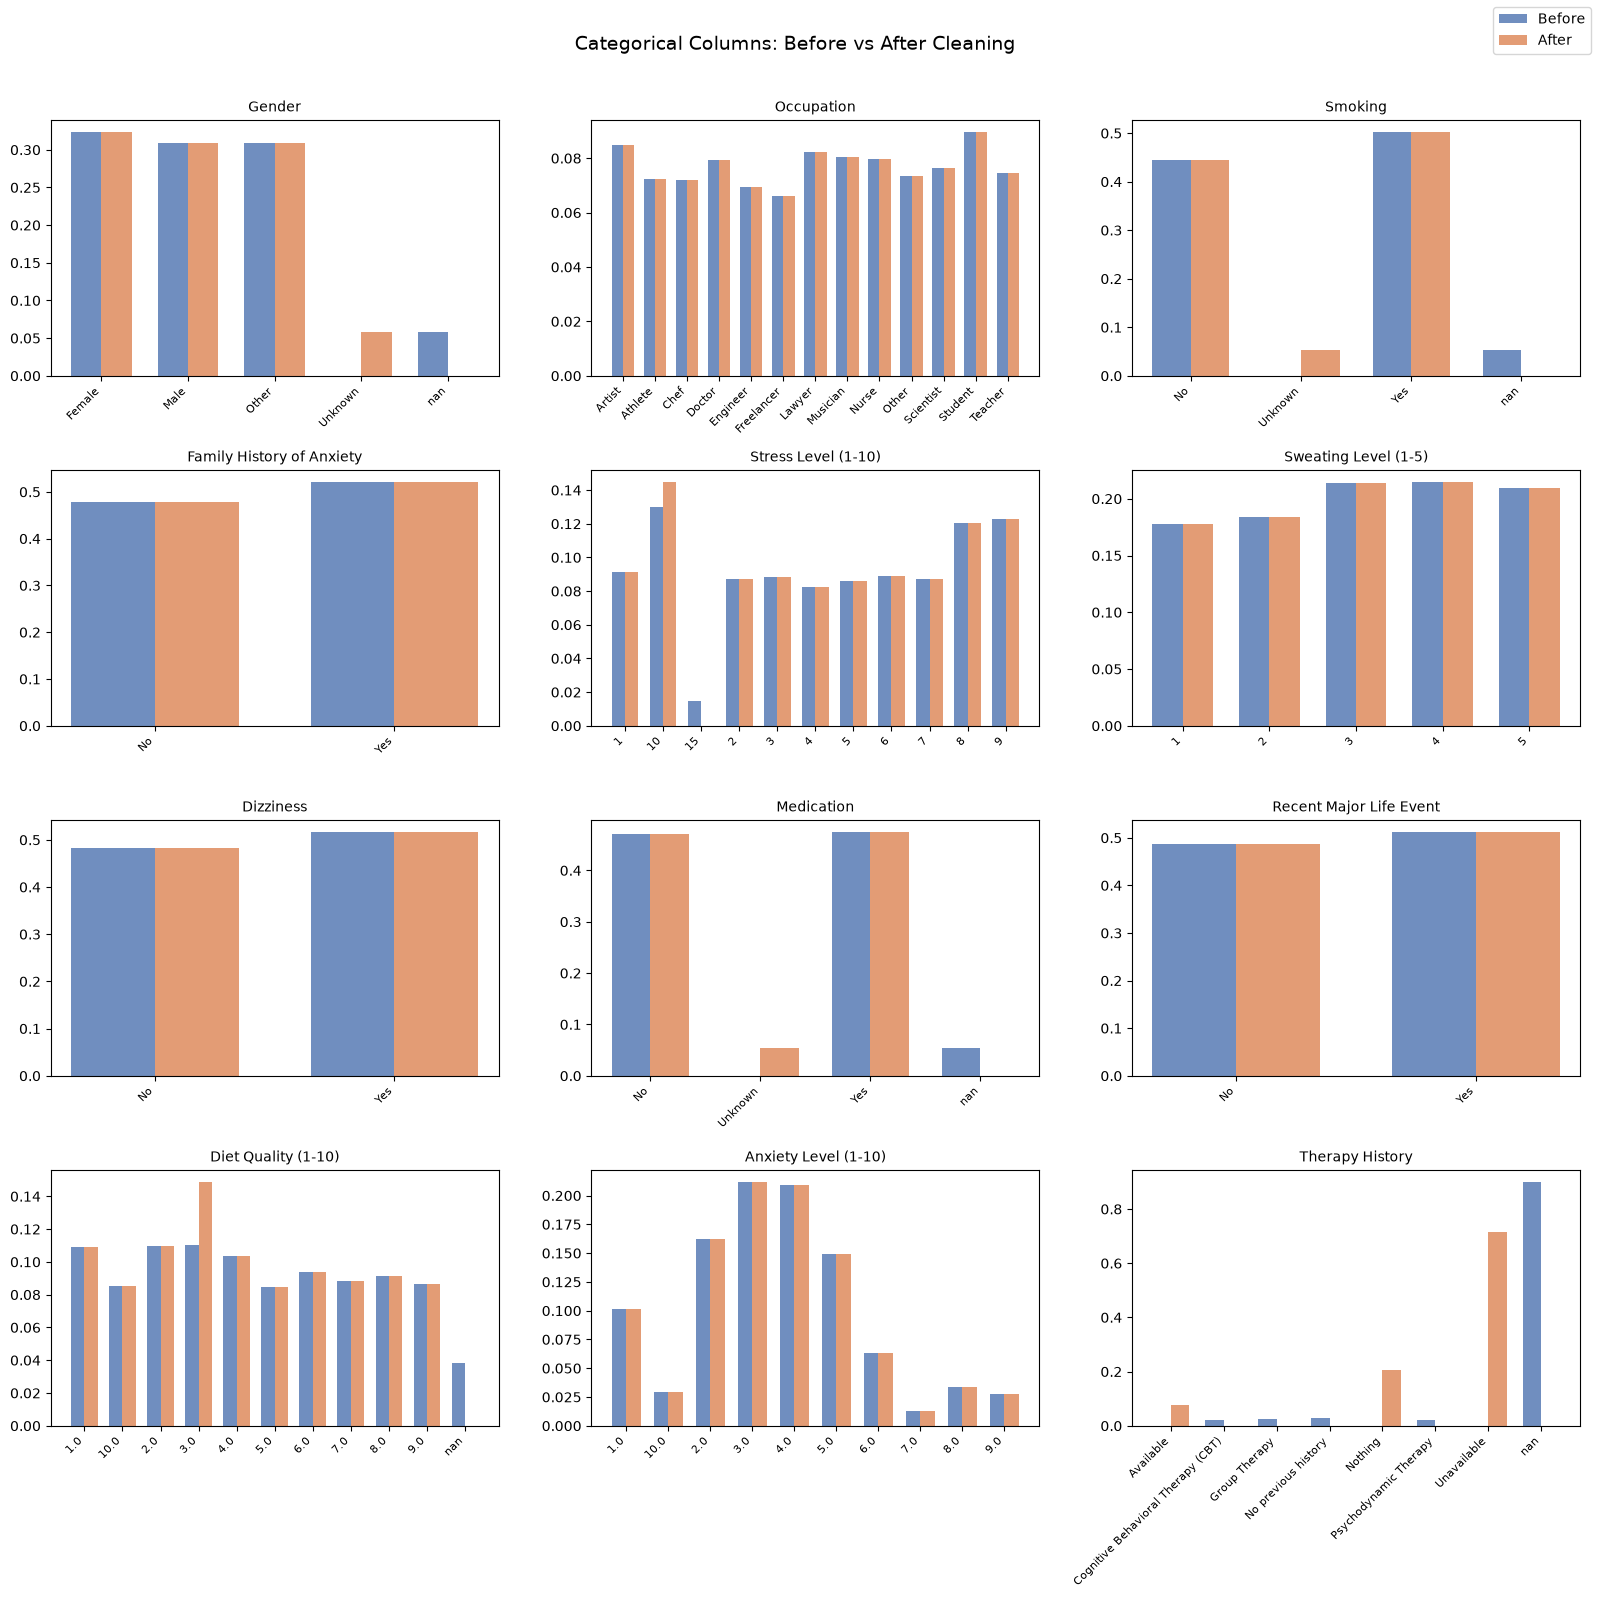

In [111]:
plotted_categorical_columns = [c for c in categorical_columns if c in df.columns]

fig, axes = plt.subplots(4, 3, figsize=(16, 16))
axes = axes.flatten()

for ax, column in zip(axes, plotted_categorical_columns):
    before_counts = df_raw[column].value_counts(normalize=True, dropna=False)
    after_counts = df[column].value_counts(normalize=True, dropna=False)

    categories = sorted(set(before_counts.index) | set(after_counts.index), key=str)
    x = range(len(categories))
    width = 0.35

    before_values = [before_counts.get(c, 0) for c in categories]
    after_values = [after_counts.get(c, 0) for c in categories]

    ax.bar([i - width / 2 for i in x], before_values, width, label="Before", color=before_color, alpha=0.8)
    ax.bar([i + width / 2 for i in x], after_values, width, label="After", color=after_color, alpha=0.8)

    ax.set_xticks(list(x))
    ax.set_xticklabels([str(c) for c in categories], rotation=45, ha="right", fontsize=8)
    ax.set_title(column, fontsize=10)

for ax in axes[len(plotted_categorical_columns):]:
    ax.axis("off")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")
fig.suptitle("Categorical Columns: Before vs After Cleaning", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

## 10. SEMANTIC BINNING & RECLASSIFYING

now the columns are clean, but they are still difficult to read. `412mg` of caffeine or `5.4` hours of sleep means nothing alone — the number receives a judgement only when we compare it with a reference.

in this section we add a second version of every measurement, in simple words. we don't touch the original columns, so at the end the dataset keeps the two things: the exact value and its interpretation.

### Semantic binning

to cut a measurement into groups is useful only if the limits have a meaning. if we cut `Sleep Hours` on its own quartiles we obtain four groups of the same size but without any meaning. so all the limits below come from published health guidelines, and like this every limit is a real threshold.

| column | derived column | thresholds | reference |
|---|---|---|---|
| `Age` | `Age Group` | 25 / 40 / 55 | conventional life stages |
| `Sleep Hours` | `Sleep Category` | 6 / 7 / 9 | 7-9h recommended for adults |
| `Physical Activity (hrs/week)` | `Activity Level` | 1 / 2.5 / 5 | 150 min/week of moderate activity (2.5h) |
| `Caffeine Intake (mg/day)` | `Caffeine Level` | 100 / 250 / 400 | 400mg/day is the upper limit for healthy adults |
| `Alcohol Consumption (drinks/week)` | `Drinking Level` | 1 / 8 / 15 |  moderate drinking is until 7-14 drinks/week |
| `Heart Rate (bpm)` | `Heart Rate Category` | 60 / 100 / 120 | the resting adult range is 60-100 bpm |
| `Breathing Rate (breaths/min)` | `Breathing Category` | 12 / 20 / 25 | the resting adult range is 12-20 breaths/min |
| `Therapy Sessions (per month)` | `Therapy Engagement` | 1 / 3 / 5 | none / occasional / regular / intensive |

### Reclassifying

the four self-reported scales are grouped into severity bands, because this puts together the scores which say almost the same thing — on a scale of ten points, a `3` and a `4` are not really two different answers.

for `Occupation` we do a different reclassification: we group the 13 jobs into 8 sectors. when we group the similar jobs, every category becomes big enough to say something. this grouping is our own decision and not a standard, so `occupation_sectors` is the place to change it if another separation works better.

In [112]:
INF = float("inf")

semantic_bins = {
    "Age": (
        "Age Group",
        [-INF, 25, 40, 55, INF],
        ["Young Adult", "Adult", "Middle Aged", "Older Adult"],
    ),
    "Sleep Hours": (
        "Sleep Category",
        [-INF, 6, 7, 9, INF],
        ["Very Short", "Short", "Recommended", "Long"],
    ),
    "Physical Activity (hrs/week)": (
        "Activity Level",
        [-INF, 1, 2.5, 5, INF],
        ["Sedentary", "Insufficient", "Meets Guideline", "Highly Active"],
    ),
    "Caffeine Intake (mg/day)": (
        "Caffeine Level",
        [-INF, 100, 250, 400, INF],
        ["Low", "Moderate", "High", "Above Guideline"],
    ),
    "Alcohol Consumption (drinks/week)": (
        "Drinking Level",
        [-INF, 1, 8, 15, INF],
        ["None", "Light", "Moderate", "Heavy"],
    ),
    "Heart Rate (bpm)": (
        "Heart Rate Category",
        [-INF, 60, 100, 120, INF],
        ["Low", "Normal", "Elevated", "High"],
    ),
    "Breathing Rate (breaths/min)": (
        "Breathing Category",
        [-INF, 12, 20, 25, INF],
        ["Low", "Normal", "Elevated", "High"],
    ),
    "Therapy Sessions (per month)": (
        "Therapy Engagement",
        [-INF, 1, 3, 5, INF],
        ["None", "Occasional", "Regular", "Intensive"],
    ),
    "Stress Level (1-10)": (
        "Stress Band",
        [-INF, 4, 7, 9, INF],
        ["Low", "Moderate", "High", "Severe"],
    ),
    "Sweating Level (1-5)": (
        "Sweating Band",
        [-INF, 3, 4, INF],
        ["Low", "Moderate", "High"],
    ),
    "Diet Quality (1-10)": (
        "Diet Category",
        [-INF, 4, 7, 9, INF],
        ["Poor", "Fair", "Good", "Excellent"],
    ),
    "Anxiety Level (1-10)": (
        "Anxiety Severity",
        [-INF, 3, 5, 7, INF],
        ["Minimal", "Mild", "Moderate", "Severe"],
    ),
}

binned_columns = []

for column, (binned_column, edges, labels) in semantic_bins.items():
    df[binned_column] = pd.cut(df[column], bins=edges, labels=labels, right=False)
    binned_columns.append(binned_column)

print(f"derived {len(binned_columns)} binned columns from {len(semantic_bins)} measurements")

derived 12 binned columns from 12 measurements


In [113]:
occupation_sectors = {
    "Doctor": "Healthcare",
    "Nurse": "Healthcare",
    "Artist": "Creative",
    "Musician": "Creative",
    "Engineer": "Technical",
    "Scientist": "Technical",
    "Teacher": "Professional",
    "Lawyer": "Professional",
    "Chef": "Service",
    "Athlete": "Service",
    "Student": "Student",
    "Freelancer": "Freelance",
    "Other": "Other",
}

unmapped = set(df["Occupation"].unique()) - set(occupation_sectors)
if unmapped:
    raise ValueError(f"`Occupation` values without a sector: {sorted(unmapped)}")

df["Occupation Sector"] = df["Occupation"].map(occupation_sectors)
binned_columns.append("Occupation Sector")

print(f"reclassified {df['Occupation'].nunique()} occupations into {df['Occupation Sector'].nunique()} sectors")

reclassified 13 occupations into 8 sectors


In [114]:
n_rows = df.shape[0]

for column in binned_columns:
    counts = df[column].value_counts().sort_index()

    print(f"--- `{column}` ---")
    for value, count in counts.items():
        print(f"    {str(value):>16}: {count:>5} ({count / n_rows * 100:5.2f}%)")
    print()

print(f"missing values across derived columns: {df[binned_columns].isna().sum().sum()}")

--- `Age Group` ---
         Young Adult:   307 (15.12%)
               Adult:   722 (35.57%)
         Middle Aged:   639 (31.48%)
         Older Adult:   362 (17.83%)

--- `Sleep Category` ---
          Very Short:   504 (24.83%)
               Short:   709 (34.93%)
         Recommended:   766 (37.73%)
                Long:    51 ( 2.51%)

--- `Activity Level` ---
           Sedentary:   280 (13.79%)
        Insufficient:   566 (27.88%)
     Meets Guideline:   889 (43.79%)
       Highly Active:   295 (14.53%)

--- `Caffeine Level` ---
                 Low:   162 ( 7.98%)
            Moderate:   658 (32.41%)
                High:   752 (37.04%)
     Above Guideline:   458 (22.56%)

--- `Drinking Level` ---
                None:    95 ( 4.68%)
               Light:   658 (32.41%)
            Moderate:   747 (36.80%)
               Heavy:   530 (26.11%)

--- `Heart Rate Category` ---
                 Low:     0 ( 0.00%)
              Normal:  1260 (62.07%)
            Elevated:   740 (36

# 11. ANXIETY INDICATORS

until now every column describes a person with one measurement at a time. but the anxiety is not like this. in the clinical and public health literature it is described like a pattern which exists on several measurements together: a body which stays in a state of arousal, a life which asks more than the person can recover, and an inherited vulnerability which some event activates.

one single column cannot express these patterns, because each one is a *combination*. so in this section we build five indicators, and each one takes a pattern described by the research and transforms it into one column that we can read.
---

### `Somatic Arousal Score` (0-4)

**The research.** The anxiety has a physical signature: the heart beats faster, the breathing becomes quicker, the sweating increases, and the dizziness can arrive after this change of the breathing.

### `Recovery Capacity` (0-3)

**The research.** The sleep, the physical activity and the diet are the three lifestyle factors which are the most constantly associated with the mental health in the public health guidelines, and the person can change the three of them. This indicator counts how many of them the person respects: the sleep inside the recommended range, the activity on the guideline or above it, and a good quality of diet.

### `Stress-Recovery Balance` (Overloaded / Buffered / Coasting / Resilient)

**The research.** In general the stress research considers the strain like the *difference* between what the situation demands from the person and the resources that this person has to support it, and not like the demand alone. two persons under the same pressure can have very different results, depending on what they have behind them.

### `Sleep-Caffeine Cycle` (0/1)

**The research.** The short sleep and the high consumption of caffeine are documented like two things which reinforce each other: a bad sleep pushes the person to drink more caffeine, and the caffeine makes the sleep of the next night worse again. in addition the caffeine is recognised like a stimulant which can provoke directly the symptoms of anxiety, and this is the reason why a guideline of consumption exists.

### `Inherited Risk Triggered` (0/1)

**The research.** This flag marks the persons who have the two conditions: a family history of anxiety, and a recent major life event.

In [115]:
df["Somatic Arousal Score"] = (
    df["Heart Rate Category"].isin(["Elevated", "High"]).astype(int)
    + df["Breathing Category"].isin(["Elevated", "High"]).astype(int)
    + df["Sweating Band"].eq("High").astype(int)
    + df["Dizziness"].eq("Yes").astype(int)
)

df["Recovery Capacity"] = (
    df["Sleep Category"].eq("Recommended").astype(int)
    + df["Activity Level"].isin(["Meets Guideline", "Highly Active"]).astype(int)
    + df["Diet Category"].isin(["Good", "Excellent"]).astype(int)
)

under_stress = df["Stress Band"].isin(["High", "Severe"])
depleted = df["Recovery Capacity"] <= 1

df["Stress-Recovery Balance"] = "Resilient"
df.loc[~under_stress & depleted, "Stress-Recovery Balance"] = "Coasting"
df.loc[under_stress & ~depleted, "Stress-Recovery Balance"] = "Buffered"
df.loc[under_stress & depleted, "Stress-Recovery Balance"] = "Overloaded"

df["Sleep-Caffeine Cycle"] = (
    df["Sleep Category"].isin(["Very Short", "Short"])
    & df["Caffeine Level"].isin(["High", "Above Guideline"])
).astype(int)

df["Inherited Risk Triggered"] = (
    df["Family History of Anxiety"].eq("Yes")
    & df["Recent Major Life Event"].eq("Yes")
).astype(int)

kpi_columns = [
    "Somatic Arousal Score",
    "Recovery Capacity",
    "Stress-Recovery Balance",
    "Sleep-Caffeine Cycle",
    "Inherited Risk Triggered",
]

base_rate = df["Target"].mean()

for column in kpi_columns:
    summary = df.groupby(column, observed=True)["Target"].agg(["size", "mean"])

    print(f"--- `{column}` ---")
    for value, row in summary.iterrows():
        print(
            f"    {str(value):>12}: {int(row['size']):>5} rows"
            f" | anxious {row['mean'] * 100:5.2f}%"
            f" | lift {row['mean'] / base_rate:4.2f}x"
        )
    print()

--- `Somatic Arousal Score` ---
               0:   162 rows | anxious  1.85% | lift 0.18x
               1:   543 rows | anxious  2.03% | lift 0.20x
               2:   739 rows | anxious  6.77% | lift 0.65x
               3:   469 rows | anxious 20.47% | lift 1.98x
               4:   117 rows | anxious 42.74% | lift 4.13x

--- `Recovery Capacity` ---
               0:   408 rows | anxious 43.14% | lift 4.17x
               1:   765 rows | anxious  3.14% | lift 0.30x
               2:   674 rows | anxious  1.34% | lift 0.13x
               3:   183 rows | anxious  0.55% | lift 0.05x

--- `Stress-Recovery Balance` ---
        Buffered:   345 rows | anxious  2.61% | lift 0.25x
        Coasting:   553 rows | anxious  0.00% | lift 0.00x
      Overloaded:   620 rows | anxious 32.26% | lift 3.12x
       Resilient:   512 rows | anxious  0.20% | lift 0.02x

--- `Sleep-Caffeine Cycle` ---
               0:  1264 rows | anxious  0.79% | lift 0.08x
               1:   766 rows | anxious 26.11% 

# 12. THE FINISHED DATASET

In [116]:
outlier_flags = [c for c in df.columns if c.endswith("Flag")]
original_columns = [
    c for c in df.columns
    if c not in outlier_flags + binned_columns + kpi_columns + ["Target"]
]

column_groups = {
    "original columns": original_columns,
    "outlier flags": outlier_flags,
    "binned columns": binned_columns,
    "anxiety indicators": kpi_columns,
    "is_anxious": ["Target"],
}

print(f"{df_raw.shape[0]} rows x {df_raw.shape[1]} columns  ->  {df.shape[0]} rows x {df.shape[1]} columns")
print(f"missing values: {df.isna().sum().sum()}")
print()

df

2030 rows x 22 columns  ->  2030 rows x 45 columns
missing values: 0



,Age,Gender,Occupation,Sleep Hours,Physical Activity (hrs/week),Caffeine Intake (mg/day),Alcohol Consumption (drinks/week),Smoking,Family History of Anxiety,Stress Level (1-10),...,Stress Band,Sweating Band,Diet Category,Anxiety Severity,Occupation Sector,Somatic Arousal Score,Recovery Capacity,Stress-Recovery Balance,Sleep-Caffeine Cycle,Inherited Risk Triggered
0,59.0,Other,Teacher,7.00,2.4,40.0,5.000000,Yes,No,4,...,Moderate,High,Poor,Minimal,Professional,2,1,Coasting,0,0
1,46.0,Female,Student,5.10,5.4,156.0,11.000000,Unknown,No,3,...,Low,High,Poor,Mild,Student,2,1,Coasting,0,0
2,40.0,Other,Lawyer,5.10,1.9,570.0,14.000000,Yes,Yes,9,...,Severe,Moderate,Fair,Severe,Professional,2,0,Overloaded,1,1
3,40.0,Male,Nurse,7.60,0.9,129.0,0.000000,No,No,9,...,Severe,Low,Poor,Moderate,Healthcare,1,1,Overloaded,0,0
4,26.0,Male,Other,6.70,3.0,64.0,13.000000,No,No,10,...,Severe,High,Fair,Mild,Other,2,1,Overloaded,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025,42.0,Male,Teacher,3.75,2.9,113.0,18.000000,Yes,Yes,4,...,Moderate,High,Poor,Mild,Professional,1,1,Coasting,0,1
2026,34.0,Other,Freelancer,8.40,2.0,239.0,14.000000,No,No,7,...,High,Low,Fair,Mild,Freelance,0,1,Overloaded,0,0
2027,62.0,Female,Musician,6.10,1.6,149.0,18.000000,Yes,No,2,...,Low,High,Good,Minimal,Creative,2,1,Coasting,0,0
2028,47.0,Other,Nurse,6.30,1.1,298.0,9.786432,No,Yes,7,...,High,Low,Poor,Mild,Healthcare,2,0,Overloaded,1,1


In [117]:
df.to_csv("./social_anxiety_dataset_cleaned.csv", index=False)